In [1]:
# ! pip install -U langchain_community beautifulsoup4 langchain-text-splitters langchain-core langchain-openai \n
#  chromadb grandalf -q

#### 00 - Dependencies

In [2]:
import os

os.environ["LLM_API_KEY"] = os.environ.get("LLM_API_KEY", "")
os.environ["LLM_BASE_URL"] = os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1")
os.environ["LLM_MODEL"] = os.environ.get("LLM_MODEL", "openai/gpt-4o-mini")
os.environ["LLM_TEMPERATURE"] = os.environ.get("LLM_TEMPERATURE", "0")

#### 1.0 - Data

- load
- split
- embed

In [3]:
from langchain_community.document_loaders import WebBaseLoader
import bs4

url = "https://claude.com/blog/millennium-and-anthropic-are-building-a-digital-risk-analyst-with-claude"
classes = ["u-rich-text-blog u-margin-trim w-richtext"]
loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(parse_only=bs4.SoupStrainer(class_=tuple(classes))),
)
docs = loader.load()
print(len(docs), "documents loaded from the web page")

/var/folders/2r/0xf5r35d0t1330pv9d7lrq1c0000gn/T/ipykernel_19118/1689528646.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


1 documents loaded from the web page


In [4]:
import langchain
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=0,
    length_function=len,
)
splits = text_splitter.split_documents(docs)
print(len(splits), "splits created from the documents")

4 splits created from the documents


In [5]:
splits

[Document(metadata={'source': 'https://claude.com/blog/millennium-and-anthropic-are-building-a-digital-risk-analyst-with-claude'}, page_content="Anthropic is working with Millennium, one of the world's largest alternative investment management firms, to co-develop a digital risk analyst: an AI teammate to work alongside and under the supervision of the firm's risk managers to surface new risk insights and form opinions on risk exposure across asset classes.Claude and Claude Code are already used broadly across Millennium today - from trading desks and engineering to core business functions. Millennium’s digital risk analyst extends their use of Claude by helping risk managers expedite and enrich analysis of risk positions.Evaluating financial risk with Claude\xa0Investment firms have spent decades using technology to improve risk measurement, moving from traditional assessments to more complex real-time scenario analysis. Millennium’s digital risk analyst is designed to tackle critical

In [7]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = OpenAIEmbeddings(
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)

vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=embeddings)

#### 2.0 - Retrieve and Generate

- prompt
- llm
- query

In [8]:
from langchain_core.prompts import ChatPromptTemplate
prompt_template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(prompt_template)

In [9]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model=os.environ.get("LLM_MODEL", "openai/gpt-4o-mini"),
    temperature=float(os.environ.get("LLM_TEMPERATURE", "0")),
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)


In [10]:
retriever = vectorstore.as_retriever()

In [11]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)


In [12]:
question = "What is Millennium and Anthropic building together?"
answer = rag_chain.invoke(question)
answer

"Millennium and Anthropic are building a digital risk analyst, which is an AI teammate designed to work alongside and under the supervision of Millennium's risk managers to surface new risk insights and form opinions on risk exposure across asset classes."

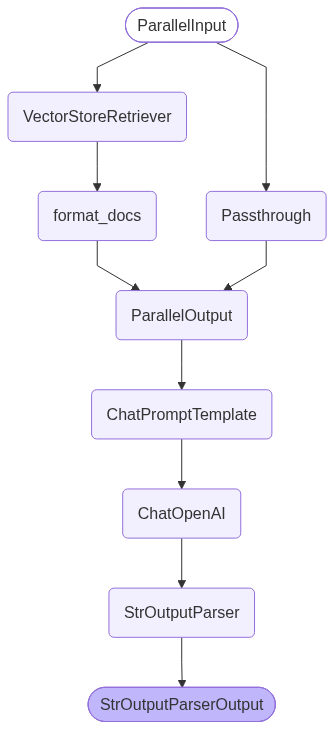

In [14]:
from IPython.display import Image
Image(rag_chain.get_graph().draw_mermaid_png())